In [3]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
llm = ChatGroq(model_name="llama-3.3-70b-versatile")

In [5]:
class llm_state(TypedDict):
    question : str
    answer : str

In [6]:
def qa(state:llm_state) -> llm_state:
    question = state['question']
    state["answer"] = llm.invoke(question)
    return state

In [7]:
graph = StateGraph(llm_state)

graph.add_node("qa",qa)

graph.add_edge(START,"qa")
graph.add_edge("qa",END)

workflow = graph.compile()

In [10]:
initial_state = {"question" : "what is python"}
final_state = workflow.invoke(initial_state)
print(final_state["answer"])

content='**Python Overview**\n====================\n\nPython is a:\n\n* **High-level programming language**: Meaning it abstracts away many low-level details, allowing developers to focus on the logic of their code.\n* **Interpreted language**: Python code is executed line by line, without the need for compilation.\n* **Object-oriented language**: Supporting concepts like classes, objects, inheritance, and polymorphism.\n* **General-purpose language**: Suitable for a wide range of applications, including web development, scientific computing, data analysis, artificial intelligence, and more.\n\n**Key Features**\n---------------\n\n* **Easy to learn**: Python has a simple syntax and is relatively easy to pick up, making it a great language for beginners.\n* **Large standard library**: Python has a vast collection of libraries and modules that make it easy to perform various tasks, such as file I/O, networking, and data analysis.\n* **Cross-platform**: Python can run on multiple operatin

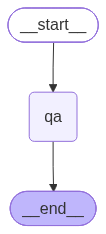

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())